In [10]:
import yaml
import pypsa
import pandas as pd
import matplotlib.pyplot as plt

In [11]:
# Load nodes yaml
with open("../models/ASEAN/nodes.yaml", "r") as file:
    nodes = yaml.safe_load(file)['nodes']

# Load links yaml
with open("../models/ASEAN/links.yaml", "r") as file:
    links = yaml.safe_load(file)['links']

# Load time definitions yaml
with open("../models/ASEAN/time_definitions.yaml", "r") as file:
    time_definition = yaml.safe_load(file)['time_definition']

# Load generators yaml
with open("../models/ASEAN/generators.yaml", "r") as file:
    generators = yaml.safe_load(file)

# Load demand yaml
with open("../models/ASEAN/demand.yaml", "r") as file:
    demand = yaml.safe_load(file)['demand']

In [12]:
network = pypsa.Network()

# ---
# set time index (snapshots)
year = time_definition['year']

snapshot = (
    pd.date_range(
        start=f'{year}-01-01 00:00:00', 
        end= f'{year}-01-02 23:00:00', 
        freq='h'
    )
)

network.set_snapshots(snapshot)

# ---
# add carriers

#emissions = {'coal': 0.34, 'gas': 0.2, 'oil': 0.26, 'hydro': 0}

network.madd(
    "Carrier",
    ['bioenergy', 'gas-ccgt', 'coal', 'diesel', 
    'geothermal', 'hydro','gas-ocgt', 'oil', 
    'solar-pv', 'waste', 'wind-offshore', 'wind-onshore'],
    #co2_emissions=emissions,
    nice_name=['bioenergy', 'gas-ccgt', 'coal', 'diesel', 
                'geothermal', 'hydro','gas-ocgt', 'oil', 
                'solar-pv', 'waste', 'wind-offshore', 'wind-onshore'],
    color=["teal", "grey", "black", "darkgray", 
    "brown", "deepskyblue", "gainsboro", "olivedrab",
    "gold", "peru", "aquamarine", "mediumseagreen"],
)

# ---
# add buses (nodes)
for node in nodes:
    network.add(
        "Bus",  # PyPSA component
        node['id'], # bus name
        x = node['coords'][1], # longitude
        y = node['coords'][0] # latitude
    )

# ---
# add lines
for link in links:
    network.add(
        "Link", 
        name=link['id'],
        bus0=link['from_node'],
        bus1=link['to_node'],
        p_nom=link['initial_capacity'],
        p_nom_extendable=link['extendable'],
        carrier=link['carrier'],
        efficiency=1,
        lifetime=99,
    )

# ---
# add generators

for technology in generators:
    for bus in technology['initial_capacity'].keys():
        network.add(
            'Generator', # PyPSA component
            bus + '-' + technology['id'], # generator name
            type = technology['id'], # technology type (e.g., solar, gas-ccgt etc.)
            bus = bus, # region/bus/balancing zone
            # ---
            # unique technology parameters by bus
            p_nom = technology['initial_capacity'][bus], # starting capacity (MW)
            p_nom_extendable = technology['extendable'], # can the model build more?
            capital_cost = technology['capital_cost'], # currency/MW
            marginal_cost = technology['marginal_cost'], # currency/MWh
            # ---
            # universal technology parameters
            carrier = technology['id'], # commodity/carrier
            lifetime = technology['lifetime'], # years
            efficiency = technology['efficiency'], # efficiency
            start_up_cost = technology['start_up_cost'], # currency/MW
            shut_down_cost = technology['shut_down_cost'], # currency/MW
            ramp_limit_up = technology['ramp_limit_up'], # per unit
            ramp_limit_down = technology['ramp_limit_up'], # per unit
            #committable = technology['committable'], # for unit commitment
        )

# ---
# add load
demand_profiles = (
    pd
    .read_csv('../data/clean/demand_profiles.csv')
    .drop('hour',axis=1)
    .iloc[0:len(network.snapshots)]
)

for bus in demand_profiles.columns:
    network.add(
        "Load", # PyPSA component
        bus, # load name
        bus=bus, # region/bus/balancing zone
        p_set=demand[0]['multiplier'][bus] * demand_profiles[bus].values # demand profile
    )

In [13]:
network.generators.carrier.unique()

array(['bioenergy', 'gas-ccgt', 'coal', 'diesel', 'geothermal', 'hydro',
       'gas-ocgt', 'oil', 'solar-pv', 'waste', 'wind-offshore',
       'wind-onshore'], dtype=object)

/Users/aman/miniconda3/envs/V20/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning:

facecolor will have no effect as it has been defined as "never".



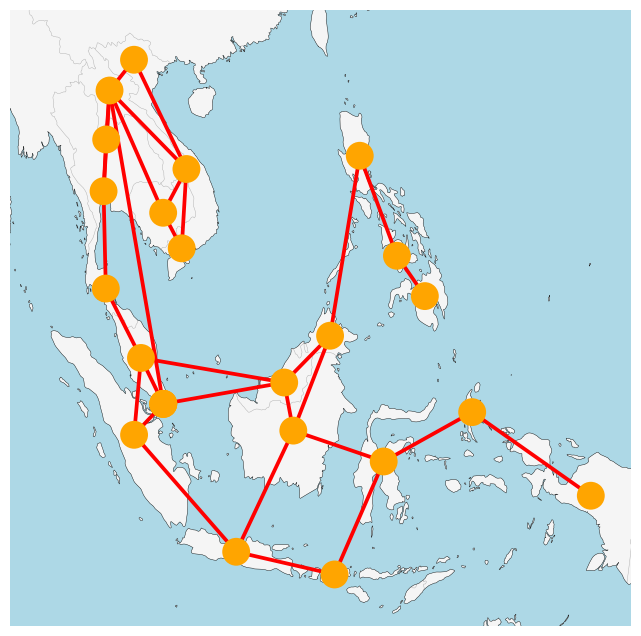

In [14]:
# ---
# plot
import cartopy.crs as ccrs

f,ax=plt.subplots(1,1,figsize=(10, 8),subplot_kw={"projection":ccrs.EqualEarth()})

# Pandas series with MultiIndex
collection = network.plot(
    bus_sizes=1,
    bus_colors='orange',
    #bus_colors={"gas": "indianred", "wind": "midnightblue"},
    margin=0.1,
    #flow=flow,
    line_widths=0,
    line_colors='red',
    link_widths=2.7,
    link_colors='red',
    #projection=ccrs.EqualEarth(),
    color_geomap=True,
    ax=ax,
)


In [15]:
network.optimize(solver_name='highs')

INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io: Writing time: 0.09s
INFO:linopy.solvers:Log file at /private/var/folders/jj/phtp57h948z6wfc9fbrdq9fr0000gp/T/highs.log.


Running HiGHS 1.5.3 [date: 2023-05-16, git hash: 594fa5a9d]
Copyright (c) 2023 HiGHS under MIT licence terms
Presolving model
8496 rows, 8985 cols, 25008 nonzeros
8496 rows, 8985 cols, 25008 nonzeros
Presolve : Reductions: rows 8496(-10504); columns 8985(-32); elements 25008(-11992)
Solving the presolved LP
Using EKK dual simplex solver - serial
  Iteration        Objective     Infeasibilities num(sum)
          0    -1.0384361300e+06 Pr: 1152(18487.8) 0s
       8742    -1.0194911900e+06 Pr: 0(0); Du: 0(6.66134e-15) 0s
Solving the original LP from the solution after postsolve
Model   status      : Optimal
Simplex   iterations: 8742
Objective value     : -1.0194911900e+06
HiGHS run time      :          0.22


INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 9017 primals, 19000 duals
Objective: -1.02e+06
Solver model: available
Solver message: optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper were not assigned to the network.


('ok', 'optimal')

In [16]:
network.objective / 1e9

-0.0010194911900056438

In [17]:
(network.statistics.capex() + network.statistics.opex()).div(1e6)

component  carrier      
Generator  bioenergy        0.002488
           coal             0.001293
           diesel           0.001193
           gas-ccgt         0.000831
           gas-ocgt         0.003259
           geothermal       0.002184
           hydro            0.003996
           oil              0.001027
           solar-pv         0.001517
           waste            0.000644
           wind-offshore    0.000036
           wind-onshore     0.000477
dtype: float64

<Axes: xlabel='bus'>

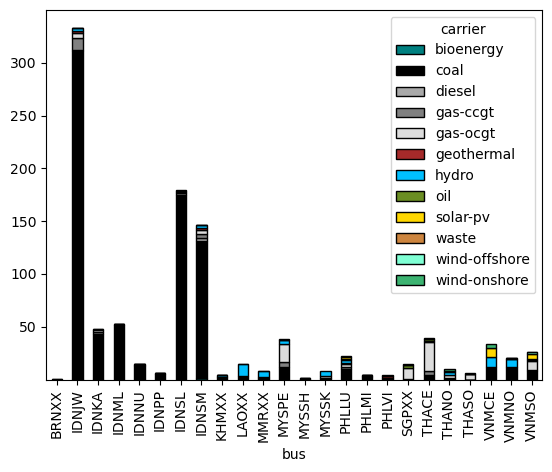

In [18]:
df = ( network
 .generators
 .groupby(['carrier','bus'])
 .sum(numeric_only=True)
 .p_nom
 .div(1e3)
 .reset_index()
 .pivot_table(index='bus',columns='carrier',values='p_nom', aggfunc='sum')
)

df.plot(
    kind='bar', 
    stacked=True, 
    color=df.columns.map(network.carriers.color),
    edgecolor='black',
) 

<Axes: xlabel='snapshot', ylabel='MW'>

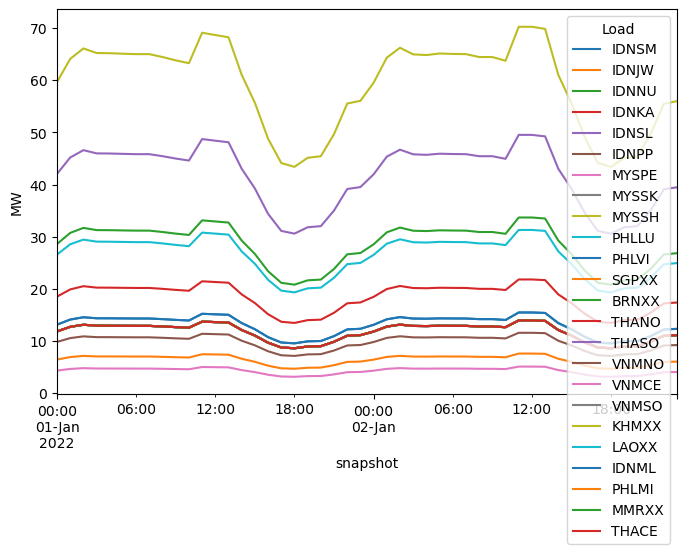

In [19]:
network.loads_t.p_set.plot(figsize=(8, 5), ylabel="MW")

/var/folders/jj/phtp57h948z6wfc9fbrdq9fr0000gp/T/ipykernel_31252/1761998587.py:2: FutureWarning:

DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.



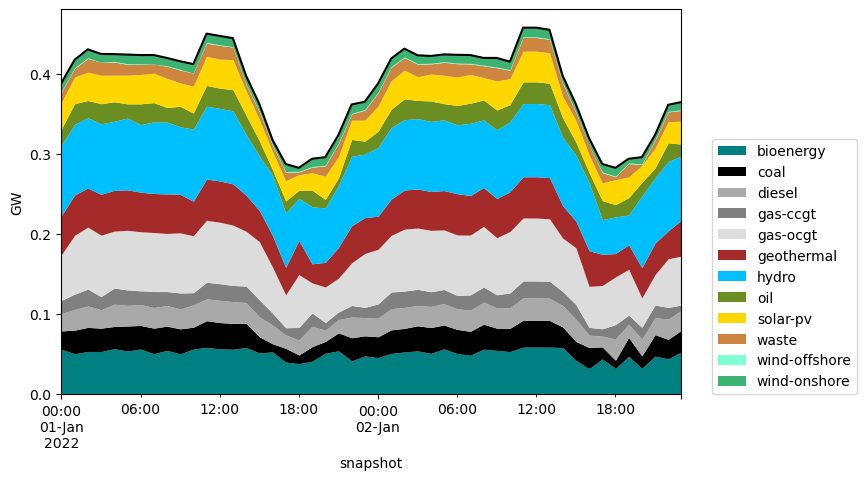

In [20]:
def plot_dispatch(n, time="2022-01"):
    p_by_carrier = n.generators_t.p.groupby(n.generators.carrier, axis=1).sum().div(1e3)

    if not n.storage_units.empty:
        sto = n.storage_units_t.p.T.groupby(n.storage_units.carrier).sum().T.div(1e3)
        p_by_carrier = pd.concat([p_by_carrier, sto], axis=1)

    fig, ax = plt.subplots(figsize=(8,5))

    color = p_by_carrier.columns.map(n.carriers.color)

    p_by_carrier.where(p_by_carrier > 0).iloc[0:24*10].plot.area(
        ax=ax,
        linewidth=0,
        color=color,
    )

    charge = p_by_carrier.where(p_by_carrier < 0).dropna(how="all", axis=1).loc[time]

    if not charge.empty:
        charge.plot.area(
            ax=ax,
            linewidth=0,
            #color=charge.columns.map(n.carriers.color),
        )

    n.loads_t.p_set.sum(axis=1).iloc[0:24*10].div(1e3).plot(ax=ax, c="k")

    plt.legend(loc=(1.05, 0))
    ax.set_ylabel("GW")
    #ax.set_ylim(-200, 200)

plot_dispatch(network)

/Users/aman/miniconda3/envs/V20/lib/python3.11/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning:

facecolor will have no effect as it has been defined as "never".



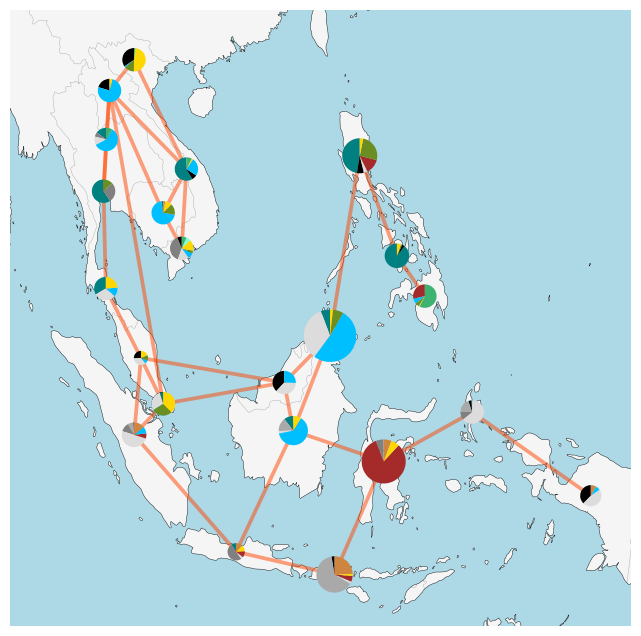

In [21]:
# ---
# plot
import cartopy.crs as ccrs

s = network.generators_t.p.sum(axis=0).groupby([network.generators.bus, network.generators.type]).sum()
flow = pd.Series(10, index=network.branches().index)

f,ax=plt.subplots(1,1,figsize=(10, 8),subplot_kw={"projection":ccrs.EqualEarth()})

# Pandas series with MultiIndex
collection = network.plot(
    bus_sizes=s / 8e2,
    #bus_colors={"gas": "indianred", "wind": "midnightblue"},
    margin=0.1,
    #flow=flow,
    line_widths=0,
    link_widths=2.7,
    link_colors='orangered',
    link_alpha=0.5,
    #projection=ccrs.EqualEarth(),
    color_geomap=True,
    line_colors=network.lines_t.p0.mean().abs(),
    ax=ax,
)

#plt.colorbar(collection[2], fraction=0.04, pad=0.004, label="Flow in MW")
plt.show()

In [22]:
s = network.generators_t.p.sum(axis=0).groupby([network.generators.bus, network.generators.type]).sum()

In [23]:
network.generators['p_nom_opt'].reset_index()

,Generator,p_nom_opt
0,IDNJW-bioenergy,0.830783
1,IDNKA-bioenergy,2.376144
2,IDNML-bioenergy,0.314384
3,IDNPP-bioenergy,-0.000000
4,IDNSL-bioenergy,-0.000000
...,...,...
148,THANO-wind-onshore,1.331834
149,THASO-wind-onshore,-0.000000
150,VNMCE-wind-onshore,1.249698
151,VNMNO-wind-onshore,0.319355


In [24]:
# asean_country_iso = ['IDN', 'MYS', 'PHL', 'SGP', 'THA', 'VNM', 'BRN', 'KHM', 'LAO', 'MMR']

# df = ( pd
#  .read_csv('../data/clean/ember-electricity-data.csv', sep=',')
# )

# ( df
#  .loc[ df['Country code'].isin(asean_country_iso)]
#  .query('Year == 2022')
#  .query('Category == "Capacity"')
#  .query('Subcategory == "Fuel"')
#  .pivot_table(index='Country code', columns='Variable', values='Value', aggfunc='sum')
#  .mul(1000)
# )